In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import json
from pathlib import Path
import geopandas as gpd

REPO_ROOT = Path("/home/sou/git/skill-migration")
DATA = REPO_ROOT / "sou" / "data"
PROC = DATA / "processed"
RAW = DATA / "raw" / "kokkai"
JOE_DATA = REPO_ROOT / "Joe" / "data" / "clean"  # READ-ONLY
FIG_DIR = REPO_ROOT / "sou" / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# CJK font: prefer IPAexGothic, fall back to NotoSansCJK-JP
_CJK_CANDIDATES = ["IPAexGothic", "Noto Sans CJK JP", "Noto Serif CJK JP", "IPAGothic"]
_available = {f.name for f in fm.fontManager.ttflist}
for _f in _CJK_CANDIDATES:
    if _f in _available:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print(f"Data dir: {DATA}")
print(f"Font: {plt.rcParams['font.family']}")
print(f"Figures dir: {FIG_DIR.relative_to(REPO_ROOT)}")

Data dir: /home/sou/git/skill-migration/sou/data
Font: ['Noto Sans CJK JP']
Figures dir: sou/notebooks/figures


In [2]:
# Load stance classifications (per-speech, 10,736 speeches)
with open(PROC / "kokkai_stances_clean.json", encoding="utf-8") as f:
    stances = json.load(f)["speech_stances"]

# Load metadata (date, party, house, speaker, etc.)
with open(RAW / "metadata.json", encoding="utf-8") as f:
    meta = json.load(f)["speeches"]

# Load full text for sample excerpts
with open(RAW / "speech_texts.json", encoding="utf-8") as f:
    texts = json.load(f)["texts"]

# Build per-speech DataFrame
records = []
for sid, s in stances.items():
    m = meta.get(sid, {})
    records.append({
        "speechID": sid,
        "label": s["label"],
        "score": s["score"],
        "n_windows": s.get("n_windows", 1),
        "date": m.get("date", ""),
        "year": m.get("date", "")[:4],
        "speaker": m.get("speaker", ""),
        "speakerYomi": m.get("speakerYomi", ""),
        "speakerGroup": m.get("speakerGroup", "") or "(no party)",
        "nameOfHouse": m.get("nameOfHouse", ""),
        "nameOfMeeting": m.get("nameOfMeeting", ""),
    })
df = pd.DataFrame(records)
df["year_num"] = pd.to_numeric(df["year"], errors="coerce")
df = df[(df["year_num"] >= 2014) & (df["year_num"] <= 2024)].copy()
print(f"Loaded {len(df):,} speeches (2014-2024)")
print(f"Label distribution: {df['label'].value_counts().to_dict()}")
print(f"House distribution: {df['nameOfHouse'].value_counts().to_dict()}")


Loaded 10,589 speeches (2014-2024)
Label distribution: {'neutral': 6905, 'anti': 2187, 'pro': 1497}
House distribution: {'衆議院': 5433, '参議院': 5153, '両院': 3}


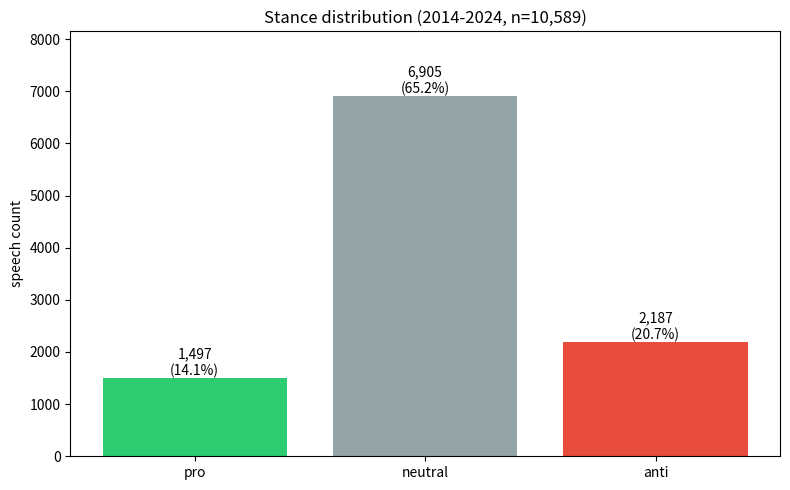

In [3]:
# Overall stance distribution
label_order = ["pro", "neutral", "anti"]
label_colors = {"pro": "#2ecc71", "neutral": "#95a5a6", "anti": "#e74c3c"}
counts = df["label"].value_counts().reindex(label_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values,
              color=[label_colors[l] for l in counts.index])
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{n:,}\n({n/len(df)*100:.1f}%)", ha="center", fontsize=10)
ax.set_ylabel("speech count")
ax.set_title("Stance distribution (2014-2024, n=" + f"{len(df):,})")
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_stance_overall.png", bbox_inches="tight")
plt.show()


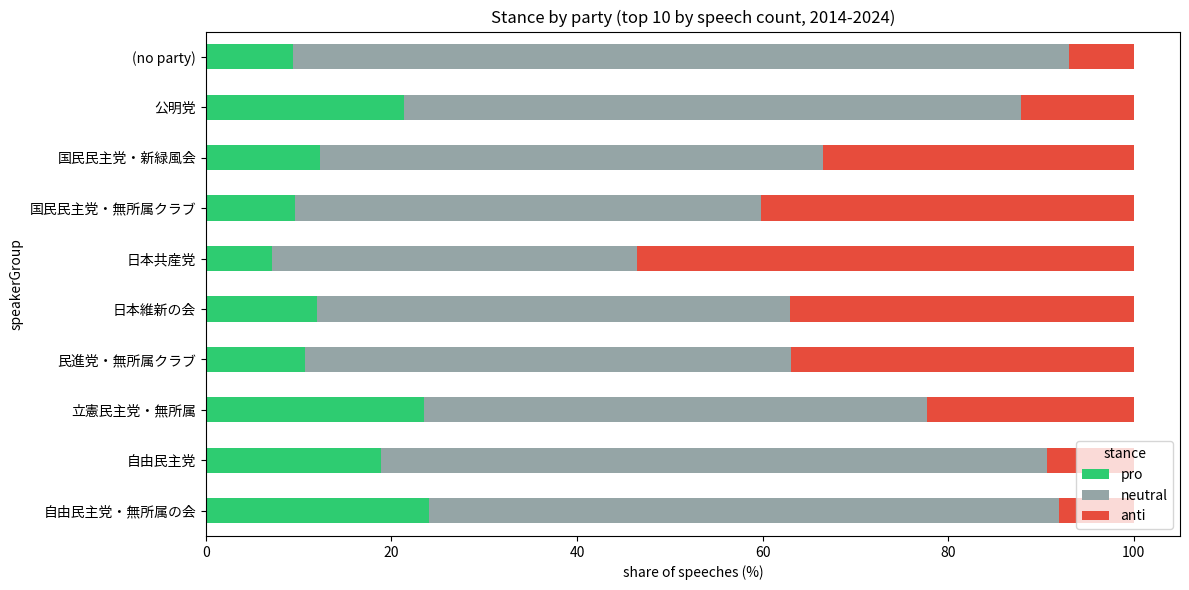

Counts:
label         pro  neutral  anti
speakerGroup                    
(no party)    274     2430   203
公明党           139      433    79
国民民主党・新緑風会     49      215   133
国民民主党・無所属クラブ   23      120    96
日本共産党          47      260   354
日本維新の会         50      213   155
民進党・無所属クラブ     22      108    76
立憲民主党・無所属      78      180    74
自由民主党         326     1242   162
自由民主党・無所属の会   205      580    69


In [4]:
# Stance distribution by party (top 10 parties by speech count)
top_parties = df["speakerGroup"].value_counts().head(10).index.tolist()
party_stance = df[df["speakerGroup"].isin(top_parties)].groupby(
    ["speakerGroup", "label"]).size().unstack(fill_value=0)
party_stance = party_stance[label_order]
party_stance_pct = party_stance.div(party_stance.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
party_stance_pct.plot(kind="barh", stacked=True, ax=ax,
                      color=[label_colors[l] for l in label_order])
ax.set_xlabel("share of speeches (%)")
ax.set_title("Stance by party (top 10 by speech count, 2014-2024)")
ax.legend(title="stance", loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_stance_by_party.png", bbox_inches="tight")
plt.show()

print("Counts:")
print(party_stance)


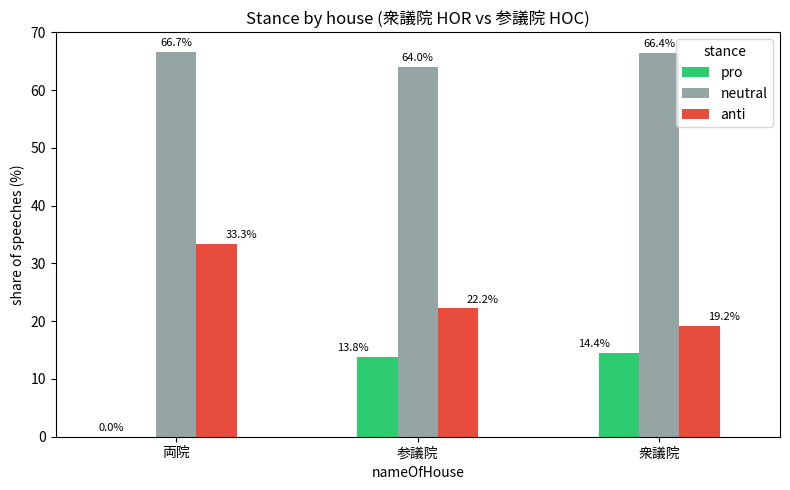

Counts:
label        pro  neutral  anti
nameOfHouse                    
両院             0        2     1
参議院          712     3296  1145
衆議院          785     3607  1041


In [5]:
# Stance by house (衆議院 HOR vs 参議院 HOC)
house_stance = df.groupby(["nameOfHouse", "label"]).size().unstack(fill_value=0)
house_stance = house_stance[label_order]
house_stance_pct = house_stance.div(house_stance.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
house_stance_pct.plot(kind="bar", ax=ax,
                      color=[label_colors[l] for l in label_order])
ax.set_ylabel("share of speeches (%)")
ax.set_title("Stance by house (衆議院 HOR vs 参議院 HOC)")
ax.legend(title="stance")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, house in enumerate(house_stance.index):
    for j, label in enumerate(label_order):
        n = house_stance.loc[house, label]
        pct = house_stance_pct.loc[house, label]
        ax.text(i + (j - 1) * 0.27, pct + 1, f"{pct:.1f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_stance_by_house.png", bbox_inches="tight")
plt.show()

print("Counts:")
print(house_stance)


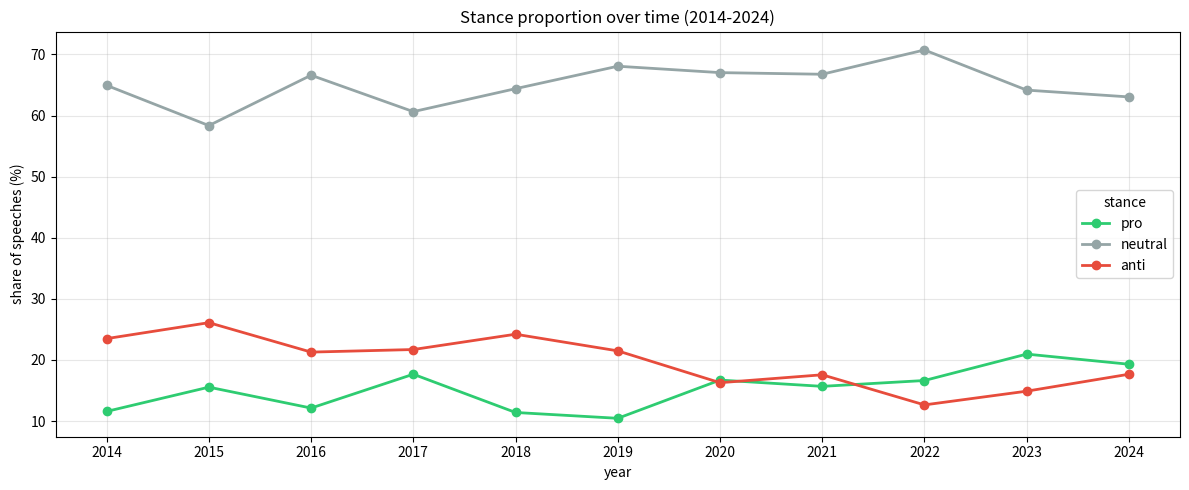

Yearly counts:
label     pro  neutral  anti
year_num                    
2014       67      376   136
2015       53      199    89
2016      176      967   309
2017       83      285   102
2018      291     1644   618
2019      176     1147   362
2020       78      313    76
2021       58      247    65
2022       75      319    57
2023      145      444   103
2024      295      964   270


In [6]:
# Stance proportion over time (yearly)
yearly = df.groupby(["year_num", "label"]).size().unstack(fill_value=0)
yearly = yearly[label_order]
yearly_pct = yearly.div(yearly.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
yearly_pct.plot(ax=ax, marker="o",
                color=[label_colors[l] for l in label_order],
                linewidth=2)
ax.set_xlabel("year")
ax.set_ylabel("share of speeches (%)")
ax.set_title("Stance proportion over time (2014-2024)")
ax.legend(title="stance")
ax.grid(True, alpha=0.3)
ax.set_xticks(range(2014, 2025))
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_stance_by_year.png", bbox_inches="tight")
plt.show()

print("Yearly counts:")
print(yearly)


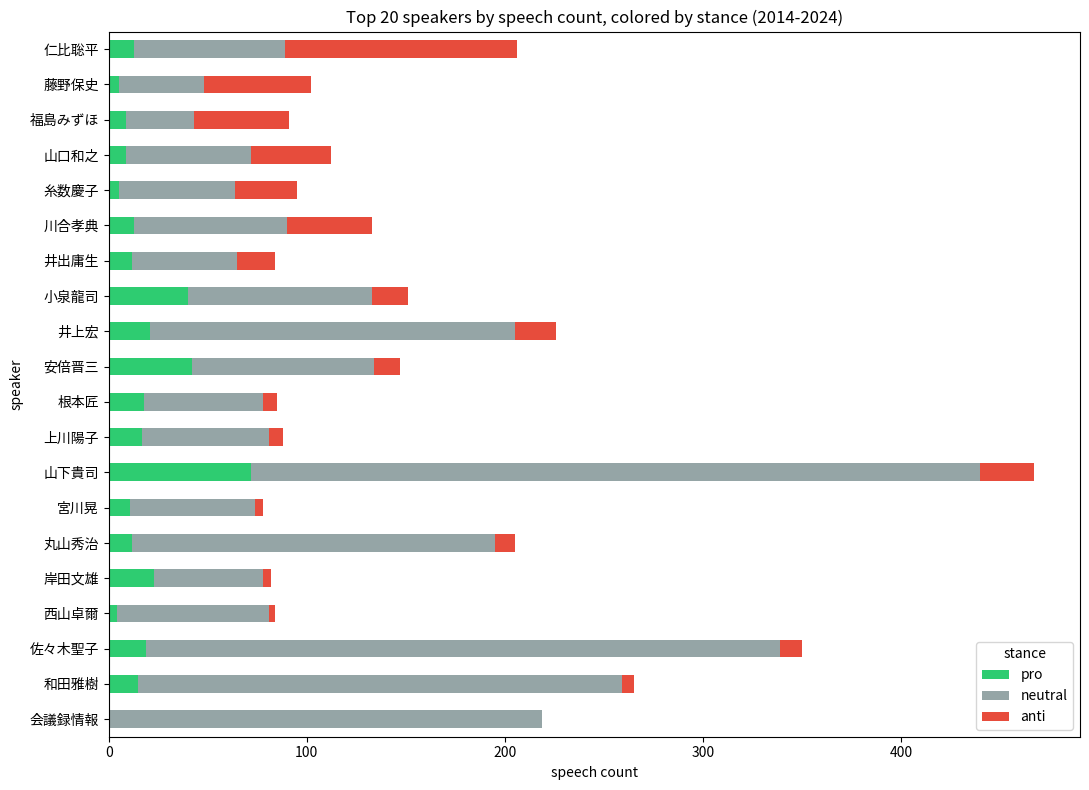

Top 20 speakers with party + house:
  仁比聡平                  参議院  日本共産党                           n= 206  anti=57%
  藤野保史                  衆議院  日本共産党                           n= 102  anti=53%
  福島みずほ                 参議院  社会民主党・護憲連合                      n=  91  anti=53%
  山口和之                  参議院  みんなの党                           n= 112  anti=36%
  糸数慶子                  参議院  各派に属しない議員                       n=  95  anti=33%
  川合孝典                  参議院  国民民主党・新緑風会                      n= 133  anti=32%
  井出庸生                  衆議院  結いの党                            n=  84  anti=23%
  小泉龍司                  衆議院  自由民主党・無所属の会                     n= 151  anti=12%
  井上宏                   衆議院  (no party)                      n= 226  anti=9%
  安倍晋三                  衆議院  自由民主党                           n= 147  anti=9%
  根本匠                   衆議院  自由民主党                           n=  85  anti=8%
  上川陽子                  衆議院  自由民主党                           n=  88  anti=8%
  山下貴司                  衆議院  自由民

In [7]:
# Top 20 most-prolific speakers, colored by stance mix
top20 = df["speaker"].value_counts().head(20).index.tolist()
sp_stance = df[df["speaker"].isin(top20)].groupby(
    ["speaker", "label"]).size().unstack(fill_value=0)
sp_stance = sp_stance[label_order]
sp_stance["total"] = sp_stance.sum(axis=1)
sp_stance["anti_pct"] = sp_stance["anti"] / sp_stance["total"] * 100
sp_stance = sp_stance.sort_values("anti_pct")

fig, ax = plt.subplots(figsize=(11, 8))
sp_stance[label_order].plot(kind="barh", stacked=True, ax=ax,
                            color=[label_colors[l] for l in label_order])
ax.set_xlabel("speech count")
ax.set_title(f"Top 20 speakers by speech count, colored by stance (2014-2024)")
ax.legend(title="stance", loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_top20_speakers.png", bbox_inches="tight")
plt.show()

# Add party annotation
sp_meta = df.drop_duplicates("speaker").set_index("speaker")[["speakerGroup", "nameOfHouse"]]
print("Top 20 speakers with party + house:")
for sp in sp_stance.index[::-1][:20]:
    n = sp_stance.loc[sp, "total"]
    party = sp_meta.loc[sp, "speakerGroup"] if sp in sp_meta.index else "?"
    house = sp_meta.loc[sp, "nameOfHouse"] if sp in sp_meta.index else "?"
    print(f"  {sp:20s}  {house}  {party:30s}  n={int(n):4d}  "
          f"anti={sp_stance.loc[sp, 'anti_pct']:.0f}%")


In [8]:
# Find one sample of each stance with text available
samples = {"pro": None, "anti": None, "neutral": None}
for sid in stances.keys():
    s_info = stances[sid]
    label = s_info["label"]
    if samples[label] is None and sid in texts:
        m = meta.get(sid, {})
        samples[label] = {
            "speechID": sid,
            "speaker": m.get("speaker", ""),
            "speakerGroup": m.get("speakerGroup", "") or "(no party)",
            "nameOfHouse": m.get("nameOfHouse", ""),
            "date": m.get("date", ""),
            "text": texts[sid],
        }
    if all(v is not None for v in samples.values()):
        break

for label in ["pro", "anti", "neutral"]:
    s = samples[label]
    print("=" * 70)
    print(f"[{label.upper()}] sample - sid={s['speechID']}")
    print(f"  date: {s['date']}, house: {s['nameOfHouse']}, party: {s['speakerGroup']}")
    print(f"  speaker: {s['speaker']}")
    print(f"  text ({len(s['text'])} chars):")
    print(f"  {s['text'][:400]}{'...' if len(s['text']) > 400 else ''}")
    print()


[PRO] sample - sid=118004080X00620120418_140
  date: 2012-04-18, house: 衆議院, party: みんなの党
  speaker: 山内康一
  text (134 chars):
  ○山内委員　ありがとうございました。
　次に、本法案の中にもジェトロの役割が書かれております。ジェトロがワンストップサービスで外国人材、外国企業の誘致の窓口になるということはいいことだと思うんですけれども、今のジェトロのそういったサービスの体制についてお伺いします。

[ANTI] sample - sid=118004260X00220120307_051
  date: 2012-03-07, house: 衆議院, party: 民主党・新緑風会
  speaker: 辻泰弘
  text (844 chars):
  ○辻副大臣　いわゆる人口置換水準といいますか、出生率二・〇七を確保しなければ人口は減少していくという中にあって、一・三台ではなかなか少子化問題は解消できないという現状にあるわけでございます。
　そういった中で、フランスの事例などもおっしゃっていただいたわけでありますけれども、フランスの移民のこと、アメリカのこともおっしゃっておられましたけれども、またＮ分Ｎ乗の御指摘もございました。
　外国人労働者の問題、直接的には牧副大臣の所掌ではございますけれども、やはり厚生労働省といたしましても、私個人のかねてよりの意見といたしましても、軽々に特定の技能、技術を持たない外国人労働者の方々に入ってきていただくということ、規制なく入っていただくということは、必ずしも日本の中長期的な社会をよくするのにつながるかどうか、その点は私は疑問を持っております。
　やはり、国民がしっかりと理解をし、合意をし、社...

[NEUTRAL] sample - sid=118004889X00120120302_016
  date: 2012-03-02, house: 衆議院, party: 民主党・無所属クラブ
  speaker: 中川正春
  text (1825 chars):
  ○中川国務大臣　「新しい公共」、少子化対策、男女共同参画を担当する内閣府特命担当大臣として、所信の一端を申し述べます。
　新しい公共

In [9]:
# Load prefecture x year x house aggregate
agg_path = PROC / "sou_kokkai_aggregates_2014_2024.csv"
if agg_path.exists():
    agg = pd.read_csv(agg_path)
    print(f"Loaded aggregate: {len(agg):,} rows (year x prefecture x house)")
    print(f"  unique prefectures: {agg['prefecture'].nunique()} (incl. 全国)")
    print(f"  unique years: {sorted(agg['year'].unique())}")
    print(f"  unique houses: {agg['house'].unique().tolist()}")
    print(f"  total speeches in aggregate: {agg['n_speeches'].sum():,}")
else:
    print(f"WARNING: Aggregate not found at {agg_path}")
    print("  Run: python3 src/aggregate_stance_by_prefecture_year.py")
    agg = None


Loaded aggregate: 523 rows (year x prefecture x house)
  unique prefectures: 46 (incl. 全国)
  unique years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  unique houses: ['参議院', '衆議院']
  total speeches in aggregate: 7,126


Matched 45/47 prefectures
pct_anti range: 0.0 - 66.6%


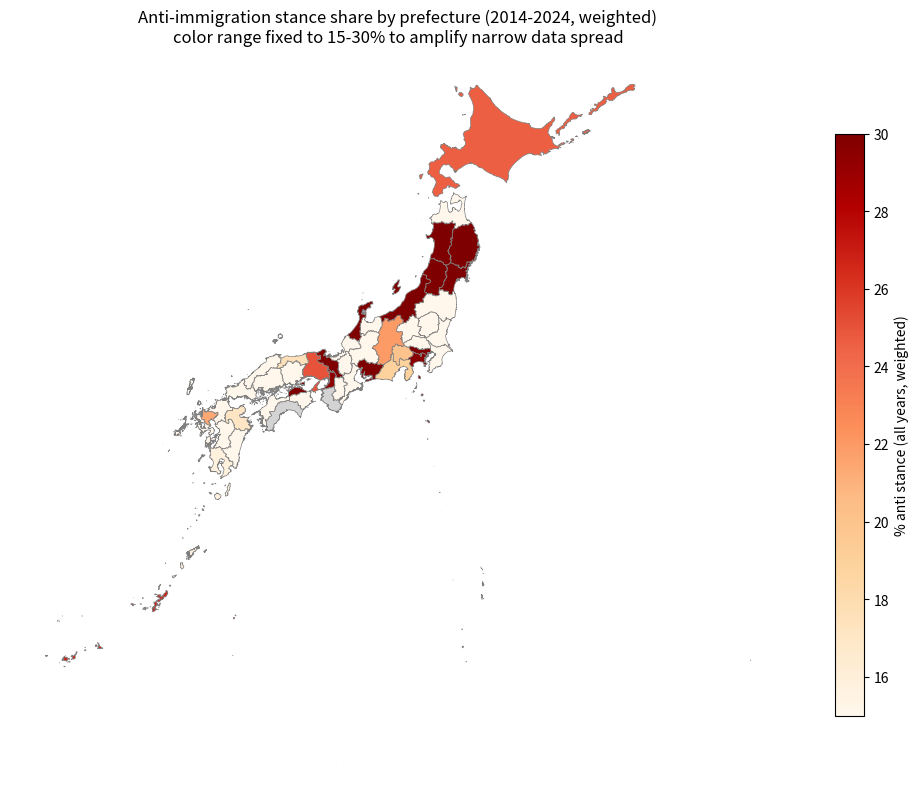

In [10]:
# Choropleth: % anti stance by prefecture (all years, weighted)
if agg is not None:
    pref_agg = (agg[agg["prefecture"] != "全国"]
                .groupby("prefecture")
                .apply(lambda g: pd.Series({
                    "n_speeches": g["n_speeches"].sum(),
                    "pct_anti_weighted": (g["pct_anti"] * g["n_speeches"]).sum() / g["n_speeches"].sum(),
                }))
                .reset_index())

    geojson_japan = "https://raw.githubusercontent.com/dataofjapan/land/master/japan.geojson"
    japan_map = gpd.read_file(geojson_japan)
    merged = japan_map.merge(pref_agg, left_on="nam_ja", right_on="prefecture", how="left")
    n_matched = merged['pct_anti_weighted'].notna().sum()
    print(f"Matched {n_matched}/47 prefectures")
    print(f"pct_anti range: {pref_agg['pct_anti_weighted'].min():.1f} - {pref_agg['pct_anti_weighted'].max():.1f}%")

    # Fix vmin/vmax to amplify the narrow data range (real range is ~22-27%, full OrRd would wash it out)
    VMIN, VMAX = 15, 30
    fig, ax = plt.subplots(figsize=(10, 10))
    merged.plot(column="pct_anti_weighted", cmap="OrRd", legend=True, ax=ax,
                vmin=VMIN, vmax=VMAX,
                legend_kwds={"label": "% anti stance (all years, weighted)", "shrink": 0.6},
                edgecolor="grey", linewidth=0.5, missing_kwds={"color": "lightgrey"})
    ax.set_title(f"Anti-immigration stance share by prefecture (2014-2024, weighted)\n"
                 f"color range fixed to {VMIN}-{VMAX}% to amplify narrow data spread")
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig6_choropleth_anti.png", bbox_inches="tight")
    plt.show()
else:
    print("Skipping - aggregate not available")

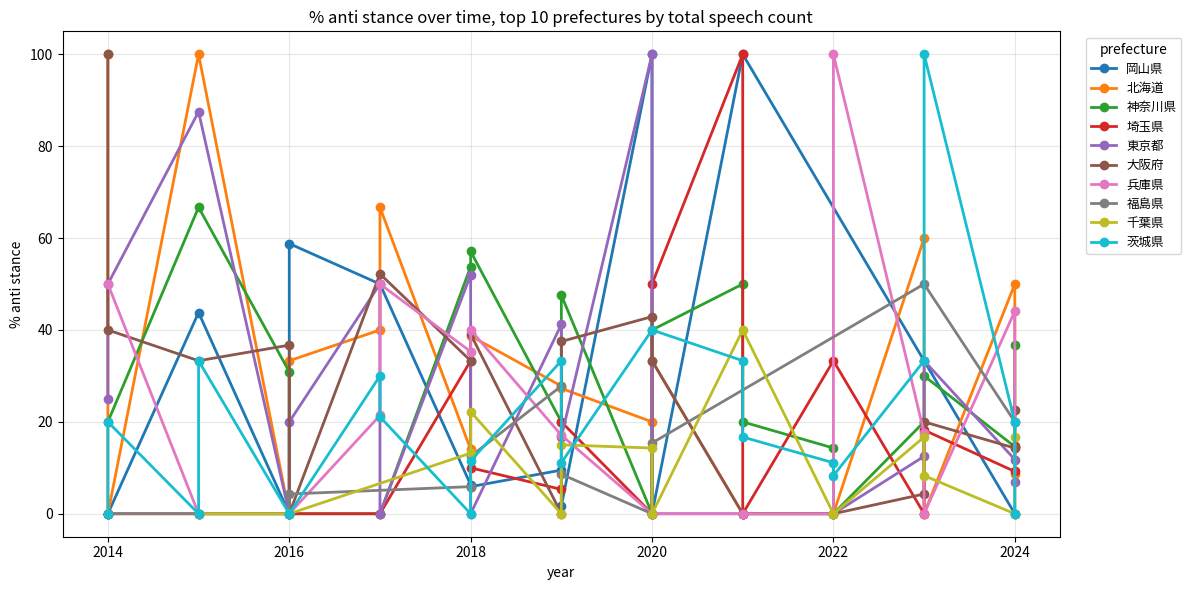

In [11]:
# Time series of % anti stance, top 10 prefectures by total speech count
if agg is not None:
    top10_pref = (agg[agg["prefecture"] != "全国"]
                  .groupby("prefecture")["n_speeches"].sum()
                  .sort_values(ascending=False).head(10).index.tolist())
    top10_df = agg[(agg["prefecture"].isin(top10_pref)) &
                   (agg["prefecture"] != "全国")].copy()

    fig, ax = plt.subplots(figsize=(12, 6))
    for pref in top10_pref:
        sub = top10_df[top10_df["prefecture"] == pref]
        ax.plot(sub["year"], sub["pct_anti"], marker="o", label=pref, linewidth=2)
    ax.set_xlabel("year")
    ax.set_ylabel("% anti stance")
    ax.set_title("% anti stance over time, top 10 prefectures by total speech count")
    ax.legend(title="prefecture", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig7_anti_timeseries_top10.png", bbox_inches="tight")
    plt.show()
else:
    print("Skipping - aggregate not available")


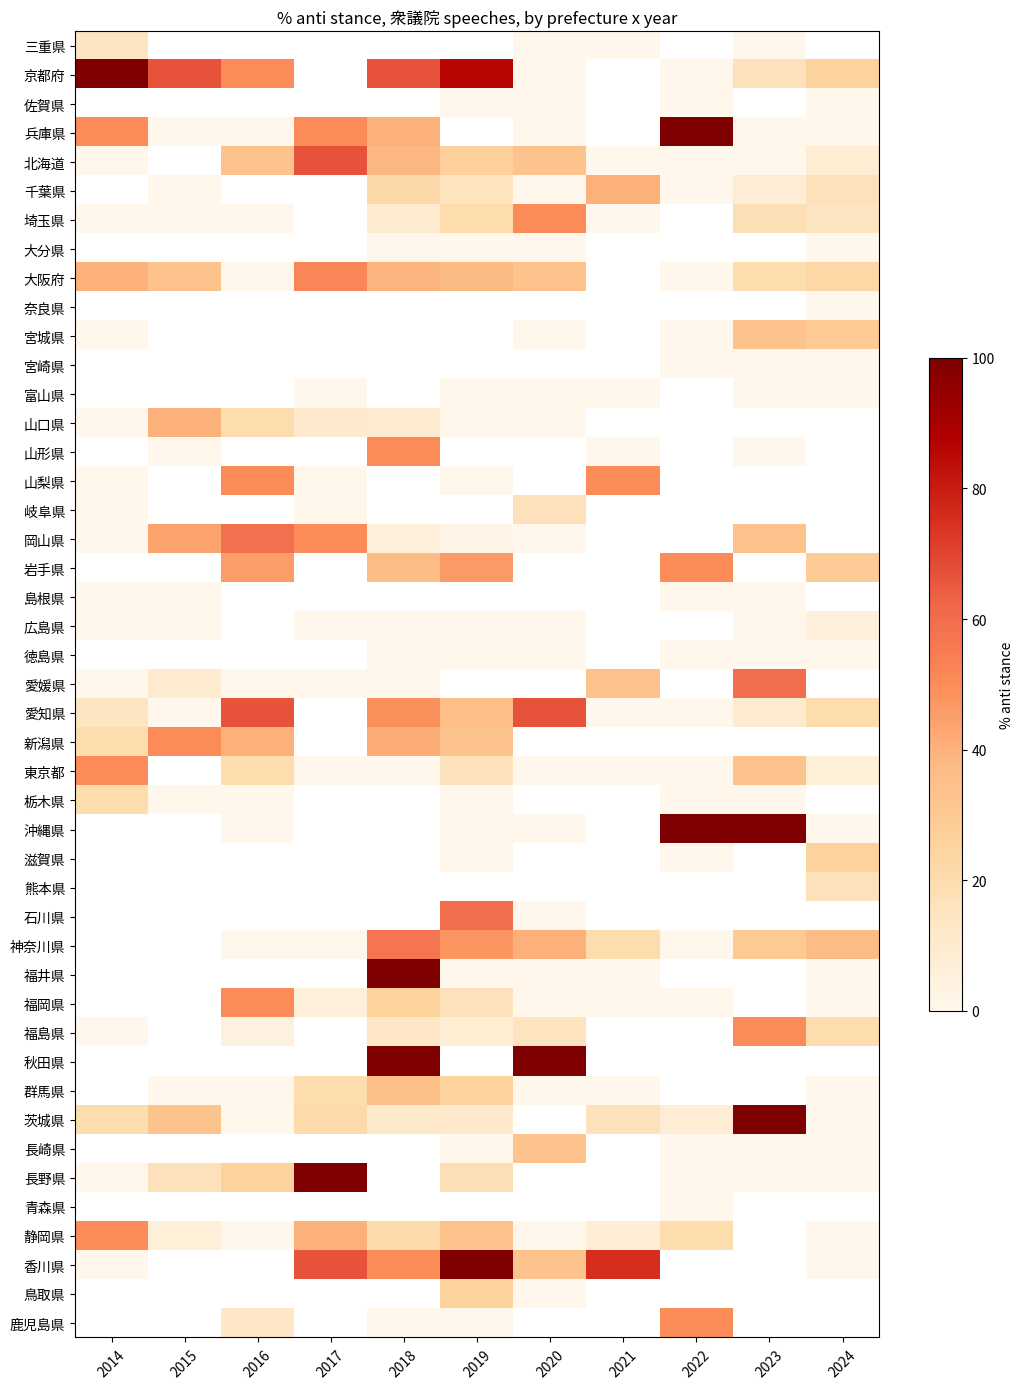

In [12]:
# Heatmap: prefecture x year, color = % anti stance (衆議院 only)
if agg is not None:
    heatmap_df = (agg[(agg["prefecture"] != "全国") & (agg["house"] == "衆議院")]
                  .pivot_table(index="prefecture", columns="year", values="pct_anti", aggfunc="mean"))

    fig, ax = plt.subplots(figsize=(11, 14))
    im = ax.imshow(heatmap_df.values, cmap="OrRd", aspect="auto")
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns, rotation=45)
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)
    ax.set_title("% anti stance, 衆議院 speeches, by prefecture x year")
    plt.colorbar(im, ax=ax, label="% anti stance", shrink=0.5)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig8_heatmap_anti.png", bbox_inches="tight")
    plt.show()
else:
    print("Skipping - aggregate not available")


In [13]:
# Load Joe's foreign resident data (READ-ONLY, no modifications)
fr_path = JOE_DATA / "immigration_data" / "foreign_resident_pop_2012-2024.csv"
jp_path = JOE_DATA / "immigration_data" / "japan_pop_2012-2024.csv"

# JP→EN map (Joe's columns use romaji)
PREF_JP2EN = {
    "北海道":"Hokkaido","青森県":"Aomori","岩手県":"Iwate","宮城県":"Miyagi","秋田県":"Akita",
    "山形県":"Yamagata","福島県":"Fukushima","茨城県":"Ibaraki","栃木県":"Tochigi","群馬県":"Gunma",
    "埼玉県":"Saitama","千葉県":"Chiba","東京都":"Tokyo","神奈川県":"Kanagawa","新潟県":"Niigata",
    "富山県":"Toyama","石川県":"Ishikawa","福井県":"Fukui","山梨県":"Yamanashi","長野県":"Nagano",
    "岐阜県":"Gifu","静岡県":"Shizuoka","愛知県":"Aichi","三重県":"Mie","滋賀県":"Shiga",
    "京都府":"Kyoto","大阪府":"Osaka","兵庫県":"Hyogo","奈良県":"Nara","和歌山県":"Wakayama",
    "鳥取県":"Tottori","島根県":"Shimane","岡山県":"Okayama","広島県":"Hiroshima","山口県":"Yamaguchi",
    "徳島県":"Tokushima","香川県":"Kagawa","愛媛県":"Ehime","高知県":"Kochi","福岡県":"Fukuoka",
    "佐賀県":"Saga","長崎県":"Nagasaki","熊本県":"Kumamoto","大分県":"Oita","宮崎県":"Miyazaki",
    "鹿児島県":"Kagoshima","沖縄県":"Okinawa",
}

if fr_path.exists() and jp_path.exists():
    fr_wide = pd.read_csv(fr_path)
    jp_wide = pd.read_csv(jp_path)
    print(f"Foreign resident data: {fr_wide.shape[0]} years x {fr_wide.shape[1] - 1} prefectures")

    fr_long = fr_wide.melt(id_vars="year", var_name="prefecture_en", value_name="foreign_pop")
    jp_long = jp_wide.melt(id_vars="year", var_name="prefecture_en", value_name="japan_pop")
    fr_long["year"] = pd.to_datetime(fr_long["year"]).dt.year
    jp_long["year"] = pd.to_datetime(jp_long["year"]).dt.year

    pop_merged = fr_long.merge(jp_long, on=["year", "prefecture_en"], how="inner")
    pop_merged["foreign_ratio_pct"] = pop_merged["foreign_pop"] / pop_merged["japan_pop"] * 100
    # Map EN → JP so we can join on our 都道府県
    en2jp = {v: k for k, v in PREF_JP2EN.items()}
    pop_merged["prefecture"] = pop_merged["prefecture_en"].map(en2jp)
    pop_merged = pop_merged.dropna(subset=["prefecture"])
    print(f"Merged long format (JP-keyed): {len(pop_merged):,} rows, {pop_merged['prefecture'].nunique()} prefectures")
    print(f"  range of foreign_ratio_pct: {pop_merged['foreign_ratio_pct'].min():.3f}% - {pop_merged['foreign_ratio_pct'].max():.3f}%")
else:
    print(f"WARNING: Joe's data not found at {JOE_DATA}")
    pop_merged = None

Foreign resident data: 13 years x 48 prefectures
Merged long format (JP-keyed): 611 rows, 47 prefectures
  range of foreign_ratio_pct: 0.291% - 5.212%


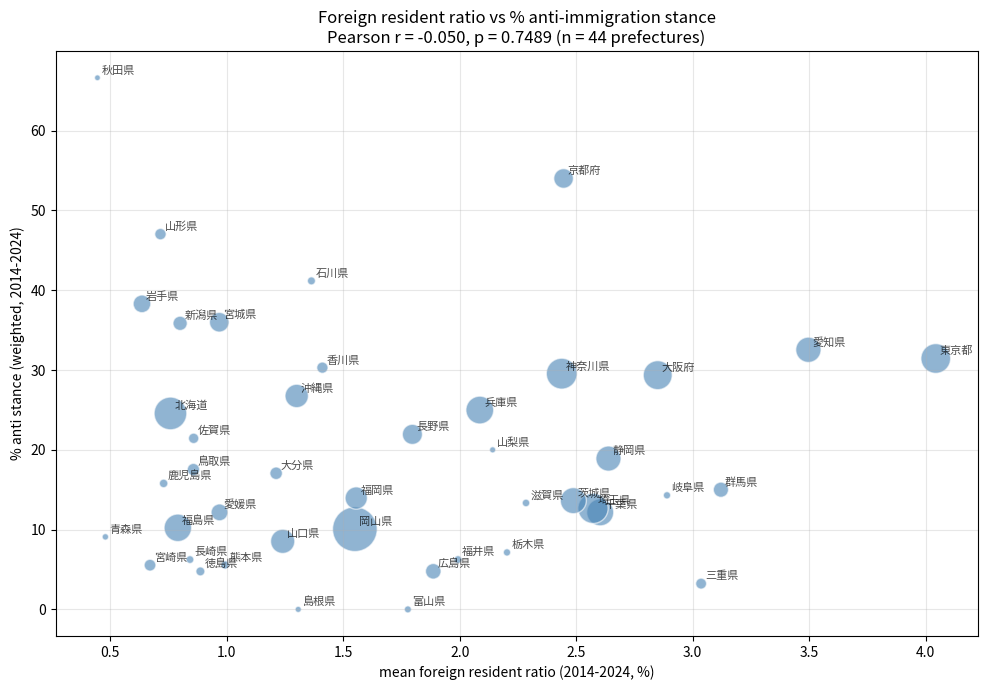


Pearson r = -0.050, p = 0.7489
Interpretation: negative correlation between foreign ratio and anti stance


In [14]:
# Cross-variable scatter: foreign resident ratio vs % anti stance
if agg is not None and pop_merged is not None:
    # Per-prefecture stance (weighted across years)
    pref_stance = (agg[agg["prefecture"] != "全国"]
                   .groupby("prefecture")
                   .apply(lambda g: pd.Series({
                       "n_speeches": g["n_speeches"].sum(),
                       "pct_anti_weighted": (g["pct_anti"] * g["n_speeches"]).sum() / g["n_speeches"].sum(),
                   }))
                   .reset_index())

    pref_foreign = (pop_merged[(pop_merged["year"] >= 2014) & (pop_merged["year"] <= 2024)]
                    .groupby("prefecture")["foreign_ratio_pct"].mean()
                    .reset_index())

    scatter_df = pref_stance.merge(pref_foreign, on="prefecture", how="inner")
    scatter_df = scatter_df[scatter_df["n_speeches"] >= 5]

    from scipy import stats
    r, p = stats.pearsonr(scatter_df["foreign_ratio_pct"], scatter_df["pct_anti_weighted"])

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(scatter_df["foreign_ratio_pct"], scatter_df["pct_anti_weighted"],
               s=scatter_df["n_speeches"] * 2, alpha=0.6, c="steelblue", edgecolor="white")
    for _, row in scatter_df.iterrows():
        ax.annotate(row["prefecture"], (row["foreign_ratio_pct"], row["pct_anti_weighted"]),
                    fontsize=8, alpha=0.7, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel("mean foreign resident ratio (2014-2024, %)")
    ax.set_ylabel("% anti stance (weighted, 2014-2024)")
    ax.set_title(f"Foreign resident ratio vs % anti-immigration stance\n"
                 f"Pearson r = {r:.3f}, p = {p:.4f} (n = {len(scatter_df)} prefectures)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig9_scatter_foreign_vs_anti.png", bbox_inches="tight")
    plt.show()

    print(f"\nPearson r = {r:.3f}, p = {p:.4f}")
    print(f"Interpretation: {'positive' if r > 0 else 'negative'} correlation between foreign ratio and anti stance")
else:
    print("Skipping - aggregate or Joe's data not available")


Matched 45/47 prefectures


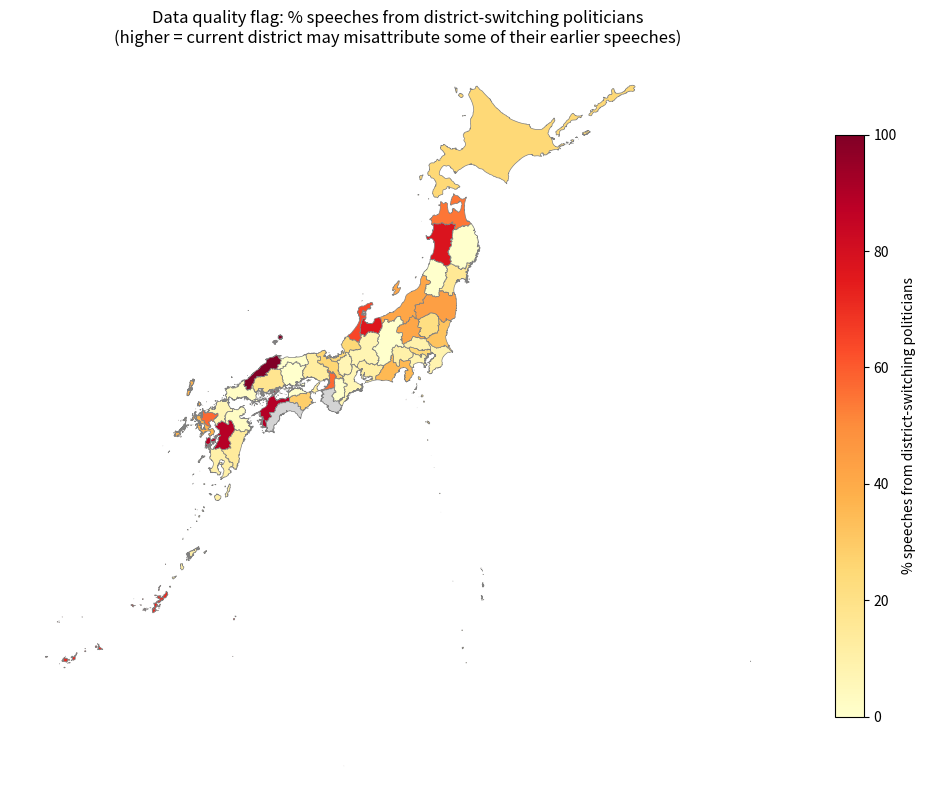


Top 10 prefectures by pct_switcher_speeches (where current-district attribution is least reliable):
prefecture  n_speeches  pct_switcher_weighted
       島根県        10.0             100.000000
       愛媛県        74.0              89.189189
       熊本県        18.0              88.900000
       秋田県         9.0              77.777778
       富山県        13.0              76.923077
       沖縄県       142.0              71.119718
       石川県        17.0              64.705882
       佐賀県        28.0              57.139286
       大阪府       218.0              56.880734
       青森県        11.0              54.545455


In [15]:
# Choropleth: pct_switcher_speeches by prefecture (data quality flag)
if agg is not None and "pct_switcher_speeches" in agg.columns:
    sw = (agg[agg["prefecture"] != "全国"]
          .groupby("prefecture")
          .apply(lambda g: pd.Series({
              "n_speeches": g["n_speeches"].sum(),
              "pct_switcher_weighted": (g["pct_switcher_speeches"] * g["n_speeches"]).sum() / g["n_speeches"].sum(),
          }))
          .reset_index())

    geojson_japan = "https://raw.githubusercontent.com/dataofjapan/land/master/japan.geojson"
    japan_map = gpd.read_file(geojson_japan)
    merged = japan_map.merge(sw, left_on="nam_ja", right_on="prefecture", how="left")
    n_matched = merged['pct_switcher_weighted'].notna().sum()
    print(f"Matched {n_matched}/47 prefectures")

    fig, ax = plt.subplots(figsize=(10, 10))
    merged.plot(column="pct_switcher_weighted", cmap="YlOrRd", legend=True, ax=ax,
                legend_kwds={"label": "% speeches from district-switching politicians", "shrink": 0.6},
                edgecolor="grey", linewidth=0.5, missing_kwds={"color": "lightgrey"})
    ax.set_title("Data quality flag: % speeches from district-switching politicians\n"
                 "(higher = current district may misattribute some of their earlier speeches)")
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig10_choropleth_switcher.png", bbox_inches="tight")
    plt.show()

    print("\nTop 10 prefectures by pct_switcher_speeches (where current-district attribution is least reliable):")
    print(sw.sort_values("pct_switcher_weighted", ascending=False).head(10).to_string(index=False))
else:
    print("Skipping - aggregate or switcher flag not available")

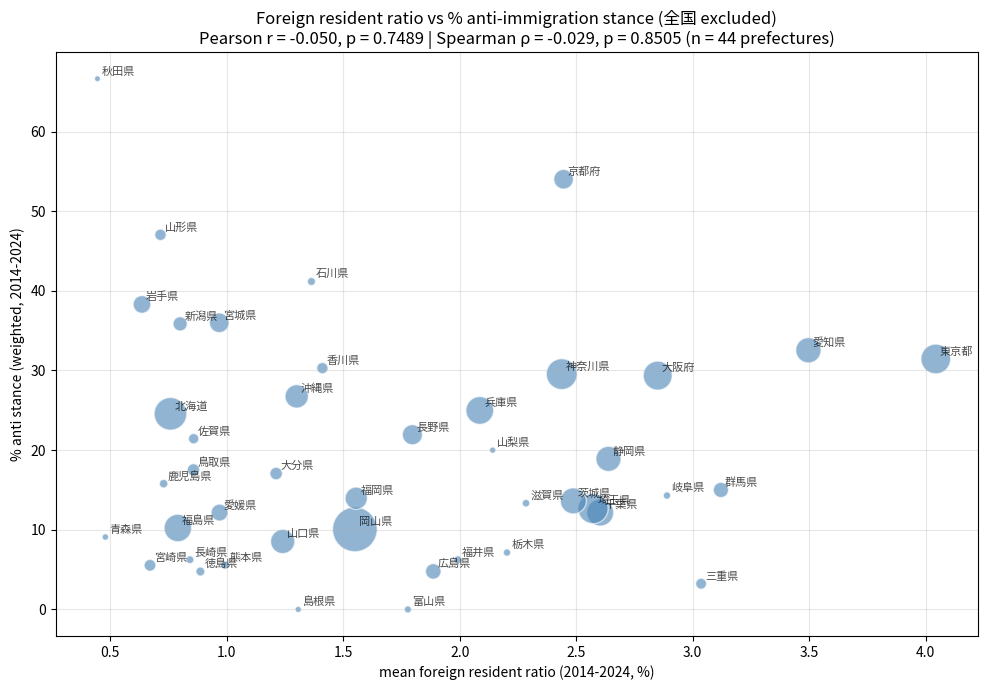

Baseline (incl. 全国):    Pearson r = -0.050, p = 0.7489
Drop 全国 (in-memory):       Pearson r = -0.050, p = 0.7489
Drop 全国 (in-memory):       Spearman ρ = -0.029, p = 0.8505
n_prefectures = 44 (after n_speeches >= 5 filter)


In [16]:
# Sensitivity: drop 全国 (HoC PR) + add Spearman rho (in-memory only)
# 全国 represents HoC proportional-representation politicians, not constituency-bound.
# Filter applied to in-memory DataFrame; aggregate file on disk is unchanged.
import scipy.stats as stats

agg_no_pr = agg[agg["prefecture"] != "全国"].copy()

pref_stance_no_pr = (agg_no_pr
                     .groupby("prefecture")
                     .apply(lambda g: pd.Series({
                         "n_speeches": g["n_speeches"].sum(),
                         "pct_anti_weighted": (g["pct_anti"] * g["n_speeches"]).sum() / g["n_speeches"].sum(),
                     }))
                     .reset_index())

pref_foreign = (pop_merged[(pop_merged["year"] >= 2014) & (pop_merged["year"] <= 2024)]
                .groupby("prefecture")["foreign_ratio_pct"].mean()
                .reset_index())

scatter_df = pref_stance_no_pr.merge(pref_foreign, on="prefecture", how="inner")
scatter_df = scatter_df[scatter_df["n_speeches"] >= 5]

r_p, p_p = stats.pearsonr(scatter_df["foreign_ratio_pct"], scatter_df["pct_anti_weighted"])
r_s, p_s = stats.spearmanr(scatter_df["foreign_ratio_pct"], scatter_df["pct_anti_weighted"])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(scatter_df["foreign_ratio_pct"], scatter_df["pct_anti_weighted"],
           s=scatter_df["n_speeches"] * 2, alpha=0.6, c="steelblue", edgecolor="white")
for _, row in scatter_df.iterrows():
    ax.annotate(row["prefecture"], (row["foreign_ratio_pct"], row["pct_anti_weighted"]),
                fontsize=8, alpha=0.7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("mean foreign resident ratio (2014-2024, %)")
ax.set_ylabel("% anti stance (weighted, 2014-2024)")
ax.set_title(f"Foreign resident ratio vs % anti-immigration stance (\u5168\u56fd excluded)\n"
             f"Pearson r = {r_p:.3f}, p = {p_p:.4f} | Spearman \u03c1 = {r_s:.3f}, p = {p_s:.4f} (n = {len(scatter_df)} prefectures)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig9b_scatter_no_PR.png", bbox_inches="tight")
plt.show()

print(f"Baseline (incl. \u5168\u56fd):    Pearson r = -0.050, p = 0.7489")
print(f"Drop \u5168\u56fd (in-memory):       Pearson r = {r_p:.3f}, p = {p_p:.4f}")
print(f"Drop \u5168\u56fd (in-memory):       Spearman \u03c1 = {r_s:.3f}, p = {p_s:.4f}")
print(f"n_prefectures = {len(scatter_df)} (after n_speeches >= 5 filter)")